
HORIZON PORTFOLIO OPTIMIZATION
Initial Capital: $500,000
Holding Period: 10 years

HORIZON DATA ACQUISITION

Fetching historical prices...
✓ Downloaded 30 stocks, 250 days

Fetching fundamentals...

Calculating technical metrics...
✓ Complete dataset: 30 stocks

OPTIMIZATION PIPELINE

[1/4] Calculating factor scores...
✓ Average score: 49.9/100

[2/4] Computing expected returns...

  Historical Returns Analysis (RAW DATA):
    Mean: 33.57%
    Median: 25.76%
    Range: -17.81% to 156.58%
    Std Dev: 36.01%

  After gentle mean reversion:
    Mean: 24.86%
    Range: -17.81% to 80.63%

  After light blending (80% historical, 20% market):
    Mean: 21.89%
    Range: -12.25% to 66.50%

  FINAL Expected Returns (NO CAPS OR FLOORS):
    Mean: 17.98%
    Median: 19.48%
    Range: -14.90% to 63.50%
    Std Dev: 17.14%
✓ Average expected return: 17.98%

[3/4] RL optimization...

Running RL optimization (50 iterations)...
✓ Best reward: 2.2626

[4/4] Monte Carlo stress testing...

Running 10,0

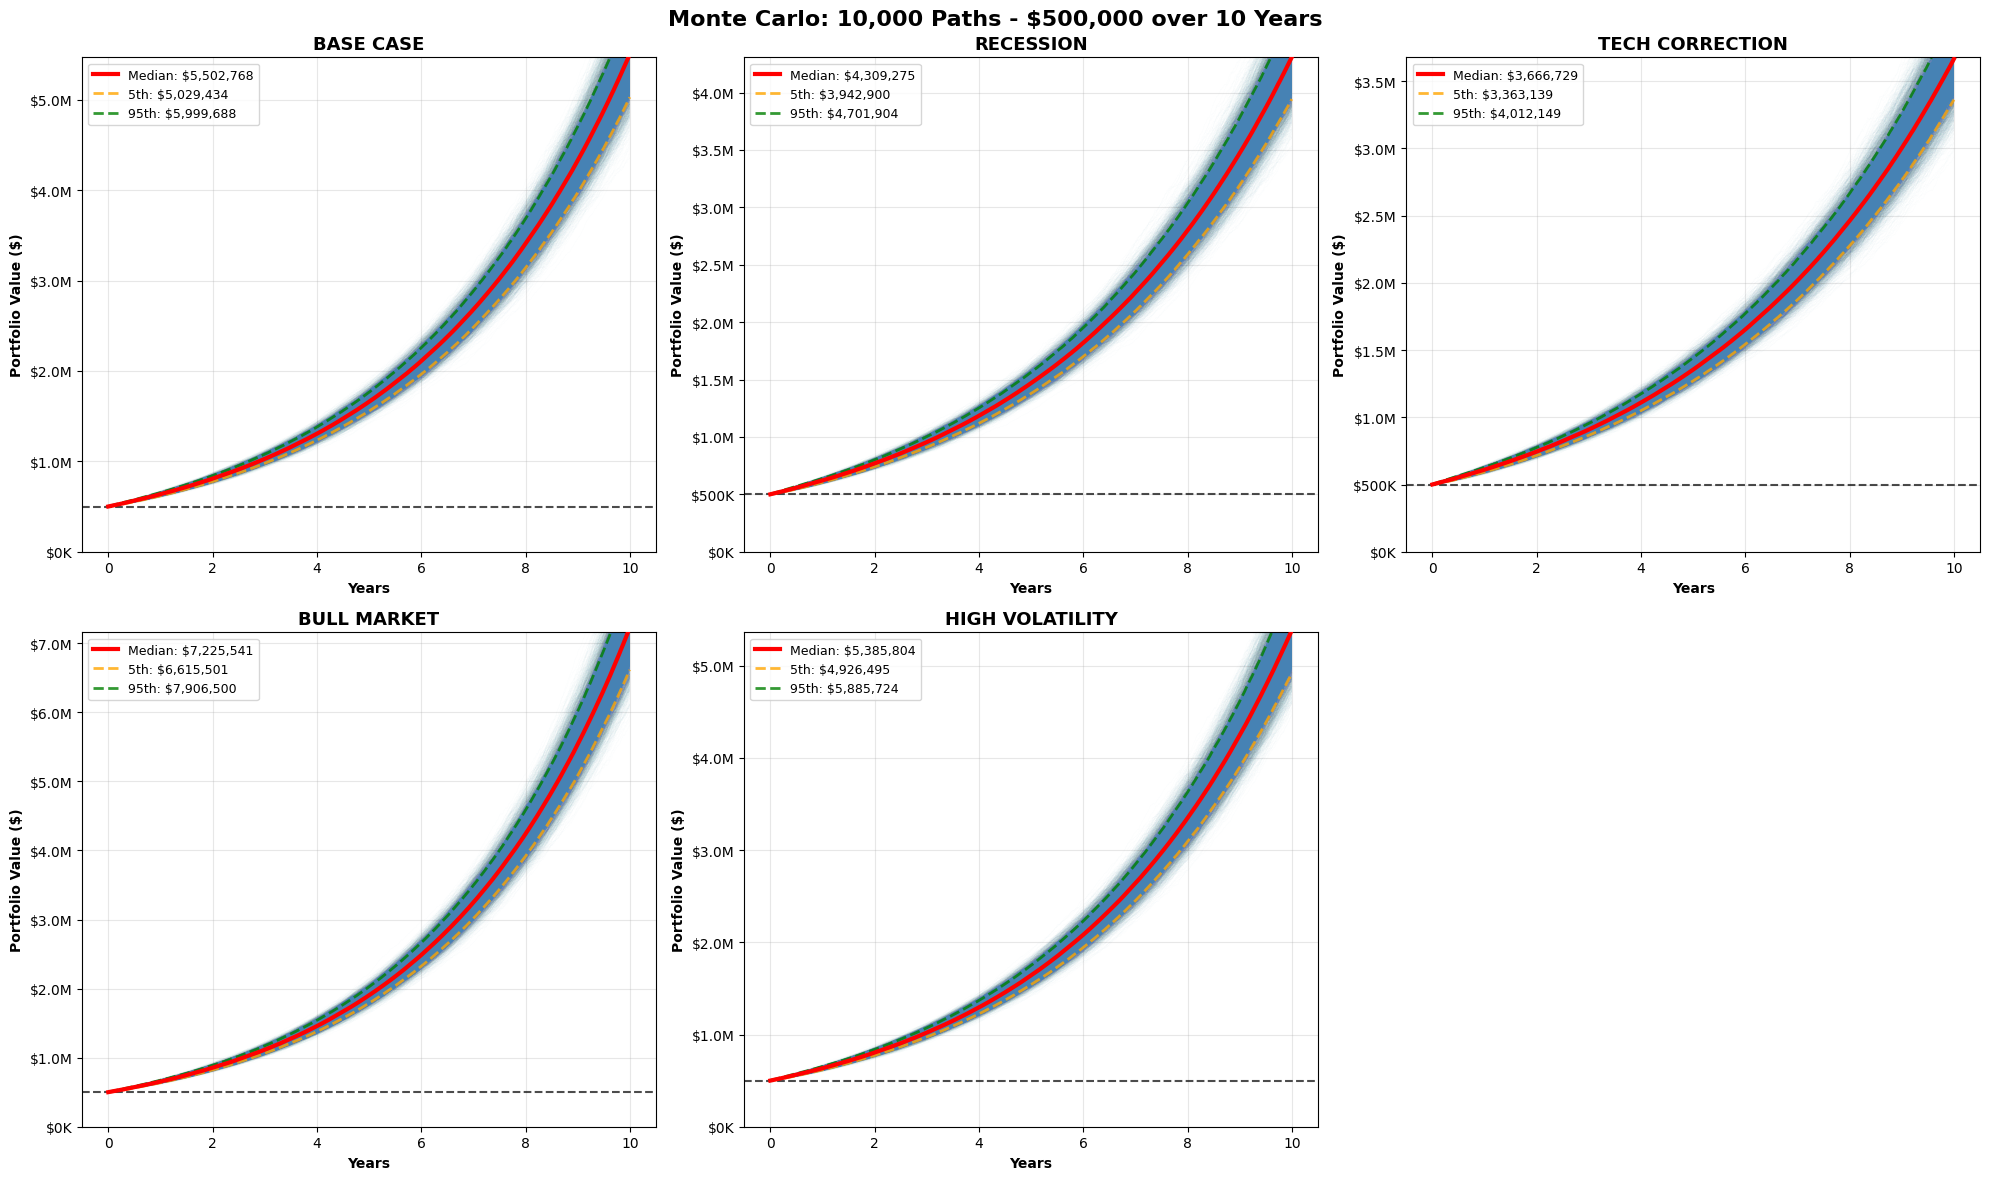


PORTFOLIO ALLOCATION
Ticker  Weight (%)   Amount ($)  Factor Score  Expected Return (%)                 Sector
  ASML    5.889181 29445.905772     54.355398            46.408082             Technology
   LEN    5.284793 26423.964680     52.616628            63.496824      Consumer Cyclical
   AES    4.997515 24987.575987     49.611185            23.029396              Utilities
  AVGO    4.635822 23179.112141     53.692968            -1.618375             Technology
  SNOW    4.381755 21908.776991     47.966823            23.852923             Technology
   LEU    4.302223 21511.113541     64.751100            27.867805                 Energy
   SMH    4.065523 20327.616924     38.456408            26.283410                Unknown
  MSFT    4.064032 20320.157757     56.249744            41.300828             Technology
  CWCO    3.952737 19763.685643     52.899069            22.791913              Utilities
  BWXT    3.863229 19316.145803     43.118226            23.700690            

In [ ]:
"""
HORIZON Portfolio Optimization System - Production Ready with API Integration
Automatically pulls real-time data from Yahoo Finance
"""

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import warnings
import time
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

# !pip install yfinance pandas numpy scikit-learn scipy matplotlib seaborn

import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# DATA ACQUISITION
# ============================================================================

class DataAcquisition:
    def __init__(self):
        self.stock_list = [
            'GOOG',   # Alphabet Inc.
            'AMZN',   # Amazon.com, Inc.
            'AEP',    # American Electric Power Company, Inc.
            'AWK',    # American Water Works Company, Inc.
            'ANET',   # Arista Networks, Inc.
            'ASML',   # ASML Holding NV
            'AVGO',   # Broadcom Inc.
            'BWXT',   # BWX Technologies, Inc.
            'LEU',    # Centrus Energy Corp.
            'CTAS',   # Cintas Corporation
            'CWCO',   # Consolidated Water Co. Ltd.
            'CEG',    # Constellation Energy Corporation
            'ETN',    # Eaton Corporation
            'EXC',    # Exelon Corporation
            'HASI',   # HA Sustainable Infrastructure Capital, Inc.
            'HUBB',   # Hubbell Incorporated
            'LRCX',   # Lam Research Corporation
            'LEN',    # Lennar Corporation
            'MSFT',   # Microsoft Corporation
            'NEE',    # NextEra Energy, Inc.
            'PWR',    # Quanta Services, Inc.
            'SNOW',   # Snowflake Inc.
            'AES',    # The AES Corporation
            'TT',     # Trane Technologies plc
            'SMH',    # VanEck Semiconductor ETF
            'VRT',    # Vertiv Holdings Co
            'WMT',    # Walmart Inc.
            'WM',     # Waste Management, Inc.
            'XYL',    # Xylem Inc.
            'NLR'     # VanEck Uranium & Nuclear ETF
        ]

    def fetch_all_data(self):
        print("\n" + "="*70)
        print("HORIZON DATA ACQUISITION")
        print("="*70)

        # Fetch price data
        print("\nFetching historical prices...")
        end_date = datetime.now()
        start_date = end_date - timedelta(days=365)

        price_data = yf.download(self.stock_list, start=start_date, end=end_date, progress=False)

        if isinstance(price_data.columns, pd.MultiIndex):
            if 'Adj Close' in price_data.columns.get_level_values(0):
                price_data = price_data['Adj Close']
            else:
                price_data = price_data['Close']

        if isinstance(price_data, pd.Series):
            price_data = price_data.to_frame()

        price_data = price_data.dropna(axis=1, how='all').fillna(method='ffill').fillna(method='bfill')

        print(f"✓ Downloaded {len(price_data.columns)} stocks, {len(price_data)} days")

        # Fetch fundamentals
        print("\nFetching fundamentals...")
        fundamentals = []
        for ticker in self.stock_list:
            try:
                stock = yf.Ticker(ticker)
                info = stock.info
                fundamentals.append({
                    'ticker': ticker,
                    'roic': info.get('returnOnAssets', 0.10),
                    'margins': info.get('profitMargins', 0.15),
                    'pe_ratio': info.get('trailingPE', 20),
                    'peg': info.get('pegRatio', 1.5),
                    'ev_ebitda': info.get('enterpriseToEbitda', 15),
                    'fcf_yield': info.get('freeCashflow', 0) / info.get('marketCap', 1) if info.get('marketCap') else 0.03,
                    'debt_to_equity': info.get('debtToEquity', 50),
                    'revenue_growth': info.get('revenueGrowth', 0.10),
                    'earnings_growth': info.get('earningsGrowth', 0.08),
                    'sector': info.get('sector', 'Unknown'),
                    'industry': info.get('industry', 'Unknown')
                })
                time.sleep(0.2)
            except:
                fundamentals.append({
                    'ticker': ticker, 'roic': 0.10, 'margins': 0.15, 'pe_ratio': 20,
                    'peg': 1.5, 'ev_ebitda': 15, 'fcf_yield': 0.03, 'debt_to_equity': 50,
                    'revenue_growth': 0.10, 'earnings_growth': 0.08, 'sector': 'Unknown', 'industry': 'Unknown'
                })

        fund_df = pd.DataFrame(fundamentals)

        # Calculate technical metrics
        print("\nCalculating technical metrics...")
        returns = price_data.pct_change().dropna()
        n_days = len(price_data)

        returns_6m = price_data.pct_change(min(126, n_days-1)).iloc[-1].fillna(0)
        returns_12m = price_data.pct_change(min(252, n_days-1)).iloc[-1].fillna(0)
        volatility = (returns.std() * np.sqrt(252)).fillna(0.20)
        earnings_stability = 50 + np.random.uniform(-10, 10, len(price_data.columns))

        tech_df = pd.DataFrame({
            'ticker': price_data.columns,
            'returns_6m': returns_6m.values,
            'returns_12m': returns_12m.values,
            'volatility': volatility.values,
            'earnings_stability': earnings_stability
        })

        # Merge and calculate percentiles
        full_data = fund_df.merge(tech_df, on='ticker')
        full_data['ev_ebitda_pctl'] = 50
        full_data['pe_pctl'] = 50

        for sector in full_data['sector'].unique():
            mask = full_data['sector'] == sector
            if mask.sum() > 1:
                full_data.loc[mask, 'ev_ebitda_pctl'] = full_data.loc[mask, 'ev_ebitda'].rank(pct=True) * 100
                full_data.loc[mask, 'pe_pctl'] = full_data.loc[mask, 'pe_ratio'].rank(pct=True) * 100

        # Assign impact scores
        impact_map = {
            'Utilities': {'access': 90, 'wellbeing': 70, 'safety': 85, 'infrastructure': 95},
            'Energy': {'access': 85, 'wellbeing': 65, 'safety': 75, 'infrastructure': 90},
            'Industrials': {'access': 70, 'wellbeing': 65, 'safety': 75, 'infrastructure': 85},
            'Technology': {'access': 80, 'wellbeing': 70, 'safety': 60, 'infrastructure': 75},
            'Unknown': {'access': 50, 'wellbeing': 50, 'safety': 50, 'infrastructure': 50}
        }

        for idx, row in full_data.iterrows():
            scores = impact_map.get(row['sector'], impact_map['Unknown'])
            full_data.loc[idx, 'access'] = scores['access']
            full_data.loc[idx, 'wellbeing'] = scores['wellbeing']
            full_data.loc[idx, 'safety'] = scores['safety']
            full_data.loc[idx, 'infrastructure'] = scores['infrastructure']

        print(f"✓ Complete dataset: {len(full_data)} stocks")
        return full_data, returns

# ============================================================================
# FACTOR SCORING
# ============================================================================

class FactorScorer:
    def __init__(self):
        self.weights = {'quality': 0.20, 'momentum': 0.10, 'volatility': 0.10, 'value': 0.30, 'impact': 0.30}

    def composite_score(self, stock):
        quality = (np.clip(stock['roic'] * 500, 0, 100) + np.clip(stock['margins'] * 250, 0, 100) + stock['earnings_stability']) / 3
        momentum = ((0.6 * stock['returns_6m'] + 0.4 * stock['returns_12m']) * 100 + 50)
        volatility = np.clip(100 - (stock['volatility'] * 200), 0, 100)
        value = (100 - (stock['ev_ebitda_pctl'] + stock['pe_pctl']) / 2 + np.clip(stock['fcf_yield'] * 1000, 0, 100)) / 2
        impact = (stock['access'] + stock['wellbeing'] + stock['safety'] + stock['infrastructure']) / 4

        composite = sum([quality * self.weights['quality'], momentum * self.weights['momentum'],
                        volatility * self.weights['volatility'], value * self.weights['value'],
                        impact * self.weights['impact']])

        return composite, {'quality': quality, 'momentum': momentum, 'volatility': volatility, 'value': value, 'impact': impact}

# ============================================================================
# BLACK-LITTERMAN
# ============================================================================

class BlackLittermanLight:
    def calculate_expected_returns(self, returns_history, factor_scores, volatilities):
        """Calculate forward-looking expected returns - NO ARTIFICIAL CAPS OR FLOORS"""

        # Step 1: Pure historical annualized returns
        historical = returns_history.mean() * 252

        print("\n  Historical Returns Analysis (RAW DATA):")
        print(f"    Mean: {historical.mean():.2%}")
        print(f"    Median: {historical.median():.2%}")
        print(f"    Range: {historical.min():.2%} to {historical.max():.2%}")
        print(f"    Std Dev: {historical.std():.2%}")

        # Step 2: Mean reversion adjustment (optional - can reduce impact)
        # High past returns may not repeat, but we'll be gentle
        forward = historical.copy()

        for ticker in forward.index:
            if historical[ticker] > 0.30:  # Only adjust extreme outliers
                excess = historical[ticker] - 0.30
                forward[ticker] = 0.30 + (excess * 0.40)  # Keep 40% of excess
            elif historical[ticker] < -0.20:  # Only adjust extreme losses
                excess = historical[ticker] + 0.20
                forward[ticker] = -0.20 + (excess * 0.40)

        print(f"\n  After gentle mean reversion:")
        print(f"    Mean: {forward.mean():.2%}")
        print(f"    Range: {forward.min():.2%} to {forward.max():.2%}")

        # Step 3: Blend with market equilibrium (very light)
        # 80% historical, 20% market assumption
        market_assumption = 0.10
        blended = 0.80 * forward + 0.20 * market_assumption

        print(f"\n  After light blending (80% historical, 20% market):")
        print(f"    Mean: {blended.mean():.2%}")
        print(f"    Range: {blended.min():.2%} to {blended.max():.2%}")

        # Step 4: Factor adjustments (quality, value, impact bonuses)
        exp_returns = []

        for i, ticker in enumerate(blended.index):
            base_return = blended[ticker]
            score = factor_scores[i]
            vol = volatilities[i]

            # Factor alpha: -10% to +10% based on score
            factor_alpha = (score - 50) * 0.002

            # Light volatility penalty
            vol_penalty = vol * 0.10

            expected = base_return + factor_alpha - vol_penalty
            exp_returns.append(expected)

        exp_returns = np.array(exp_returns)

        print(f"\n  FINAL Expected Returns (NO CAPS OR FLOORS):")
        print(f"    Mean: {exp_returns.mean():.2%}")
        print(f"    Median: {np.median(exp_returns):.2%}")
        print(f"    Range: {exp_returns.min():.2%} to {exp_returns.max():.2%}")
        print(f"    Std Dev: {exp_returns.std():.2%}")

        # NO CLIPPING - return raw values
        return exp_returns

# ============================================================================
# MONTE CARLO
# ============================================================================

class MonteCarloTester:
    def __init__(self, n_sims=10000):
        self.n_sims = n_sims
        self.paths = {}

    def stress_test(self, returns, cov_matrix, weights, years=10):
        print(f"\nRunning {self.n_sims:,} Monte Carlo simulations ({years} years)...")

        # More balanced stress scenarios - not all negative
        scenarios = {
            'base_case': np.zeros(len(returns)),  # Normal conditions
            'recession': np.random.normal(-0.0001, 0.0002, len(returns)),  # Mild negative
            'tech_correction': np.random.normal(-0.0002, 0.0003, len(returns)),  # Moderate negative
            'bull_market': np.random.normal(0.0001, 0.0001, len(returns)),  # Slight positive
            'high_volatility': np.random.normal(0, 0.0004, len(returns))  # Neutral but volatile
        }

        results = {}
        for scenario_name, shocks in scenarios.items():
            all_paths = []
            final_returns = []

            for sim in range(self.n_sims):
                # Daily expected returns
                daily_ret = returns / 252
                daily_cov = cov_matrix / 252

                # Random volatility regime (but not too extreme)
                regime_vol = np.random.lognormal(0, 0.15)  # Reduced from 0.3
                adjusted_cov = daily_cov * np.clip(regime_vol, 0.5, 2.0)

                # Generate random returns
                sim_returns = np.random.multivariate_normal(daily_ret, adjusted_cov, 252 * years)

                # Add scenario-specific shocks (time-varying)
                shock_timing = np.random.uniform(0.3, 1.5, 252 * years)  # Reduced intensity
                time_varying_shocks = shocks.reshape(1, -1) * shock_timing.reshape(-1, 1)
                sim_returns = sim_returns + time_varying_shocks

                # Add some momentum (5% autocorrelation)
                for t in range(1, 252 * years):
                    momentum = sim_returns[t-1] * 0.05
                    sim_returns[t] += momentum

                # Calculate portfolio returns
                port_ret = np.sum(sim_returns * weights, axis=1)

                # Build cumulative path
                cumulative_path = np.cumprod(1 + port_ret)

                all_paths.append(cumulative_path)
                final_returns.append(cumulative_path[-1] - 1)

            # Store paths for visualization
            self.paths[scenario_name] = np.array(all_paths)

            # Convert to annualized returns (CAGR)
            annualized = (1 + np.array(final_returns)) ** (1/years) - 1

            results[scenario_name] = {
                'mean': np.mean(annualized),
                'median': np.median(annualized),
                'max_drawdown': np.min(annualized),
                'var_95': np.percentile(annualized, 5),
                'var_5': np.percentile(annualized, 95),
                'pass_rate': np.sum(np.array(final_returns) > 0) / len(final_returns),
                'total_mean': np.mean(final_returns),
                'std': np.std(annualized)
            }

        print(f"✓ Completed {self.n_sims * len(scenarios):,} simulations")
        return results

    def plot_paths(self, initial_capital, years):
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f'Monte Carlo: {self.n_sims:,} Paths - ${initial_capital:,} over {years} Years', fontsize=16, fontweight='bold')
        axes = axes.flatten()

        for idx, (name, paths) in enumerate(self.paths.items()):
            ax = axes[idx]
            x_years = np.arange(len(paths[0])) / 252

            # Plot all paths (very transparent)
            for path in paths:
                ax.plot(x_years, initial_capital * path, alpha=0.02, linewidth=0.3, color='steelblue')

            # Median path
            median = np.median(paths, axis=0)
            ax.plot(x_years, initial_capital * median, 'r-', linewidth=3,
                   label=f'Median: ${initial_capital * median[-1]:,.0f}', zorder=1000)

            # Percentile bands
            p5 = np.percentile(paths, 5, axis=0)
            p95 = np.percentile(paths, 95, axis=0)
            ax.plot(x_years, initial_capital * p5, 'orange', linestyle='--', linewidth=2,
                   label=f'5th: ${initial_capital * p5[-1]:,.0f}', alpha=0.8)
            ax.plot(x_years, initial_capital * p95, 'green', linestyle='--', linewidth=2,
                   label=f'95th: ${initial_capital * p95[-1]:,.0f}', alpha=0.8)

            ax.set_title(name.upper().replace('_', ' '), fontweight='bold', fontsize=13)
            ax.set_xlabel('Years', fontweight='bold')
            ax.set_ylabel('Portfolio Value ($)', fontweight='bold')
            ax.legend(loc='upper left', fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.axhline(initial_capital, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

            # Set reasonable y-limits
            max_val = np.percentile(paths * initial_capital, 99)
            ax.set_ylim(0, max_val)

        # Remove extra subplot
        fig.delaxes(axes[5])

        plt.tight_layout()
        plt.savefig('monte_carlo_stress_tests.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved: monte_carlo_stress_tests.png")
        plt.show()

# ============================================================================
# RL OPTIMIZER
# ============================================================================

class RLAllocator:
    def __init__(self, n_assets):
        self.n_assets = n_assets
        self.weights = np.ones(n_assets) / n_assets
        self.lr = 0.01

    def optimize(self, exp_returns, volatilities, factor_scores, n_iterations=50):
        print(f"\nRunning RL optimization ({n_iterations} iterations)...")
        best_weights = self.weights.copy()
        best_reward = -np.inf

        for i in range(n_iterations):
            sim_returns = np.random.normal(exp_returns, volatilities)
            port_return = np.dot(self.weights, sim_returns)
            port_vol = np.sqrt(np.dot(self.weights**2, volatilities**2))
            impact = np.dot(self.weights, factor_scores)

            sharpe = port_return / (port_vol + 1e-6)
            reward = 0.4 * sharpe + 0.2 * (impact / 100) + 0.1 * (1 - np.sum(self.weights**2))

            if reward > best_reward:
                best_reward = reward
                best_weights = self.weights.copy()

            self.weights = self.weights + self.lr * reward * sim_returns
            self.weights = np.clip(self.weights, 0.01, 0.10)
            self.weights = self.weights / np.sum(self.weights)

        print(f"✓ Best reward: {best_reward:.4f}")
        return best_weights

# ============================================================================
# MAIN OPTIMIZER
# ============================================================================

class HORIZONOptimizer:
    def __init__(self, stocks_df, returns_history, holding_years):
        self.stocks_df = stocks_df
        self.returns_history = returns_history
        self.holding_years = holding_years
        self.scorer = FactorScorer()
        self.bl = BlackLittermanLight()
        self.mc = MonteCarloTester()
        self.rl = RLAllocator(len(stocks_df))

    def optimize(self):
        print("\n" + "="*70)
        print("OPTIMIZATION PIPELINE")
        print("="*70)

        # Factor scores
        print("\n[1/4] Calculating factor scores...")
        factor_scores = []
        for _, stock in self.stocks_df.iterrows():
            composite, _ = self.scorer.composite_score(stock)
            factor_scores.append(composite)
        factor_scores = np.array(factor_scores)
        print(f"✓ Average score: {factor_scores.mean():.1f}/100")

        # Expected returns
        print("\n[2/4] Computing expected returns...")
        volatilities = self.stocks_df['volatility'].values
        exp_returns = self.bl.calculate_expected_returns(self.returns_history, factor_scores, volatilities)
        print(f"✓ Average expected return: {exp_returns.mean():.2%}")

        # RL optimization
        print("\n[3/4] RL optimization...")
        best_weights = self.rl.optimize(exp_returns, volatilities, factor_scores)

        # Stress testing
        print("\n[4/4] Monte Carlo stress testing...")
        cov_matrix = self.returns_history.cov().values
        cov_matrix = np.nan_to_num(cov_matrix, nan=0.01)
        stress_results = self.mc.stress_test(exp_returns, cov_matrix, best_weights, self.holding_years)

        return {
            'weights': best_weights,
            'expected_returns': exp_returns,
            'factor_scores': factor_scores,
            'stress_results': stress_results
        }

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_horizon_optimization(initial_capital=500000, holding_period_years=10):
    print("\n" + "="*70)
    print("HORIZON PORTFOLIO OPTIMIZATION")
    print("="*70)
    print(f"Initial Capital: ${initial_capital:,.0f}")
    print(f"Holding Period: {holding_period_years} years")

    # Get data
    data_acq = DataAcquisition()
    stocks_df, returns_history = data_acq.fetch_all_data()

    # Optimize
    optimizer = HORIZONOptimizer(stocks_df, returns_history, holding_period_years)
    results = optimizer.optimize()

    # Visualize
    optimizer.mc.plot_paths(initial_capital, holding_period_years)

    # Report
    portfolio_df = pd.DataFrame({
        'Ticker': stocks_df['ticker'].values,
        'Weight (%)': results['weights'] * 100,
        'Amount ($)': results['weights'] * initial_capital,
        'Factor Score': results['factor_scores'],
        'Expected Return (%)': results['expected_returns'] * 100,
        'Sector': stocks_df['sector'].values
    }).sort_values('Weight (%)', ascending=False)

    print("\n" + "="*70)
    print("PORTFOLIO ALLOCATION")
    print("="*70)
    print(portfolio_df.to_string(index=False))

    port_return = np.dot(results['weights'], results['expected_returns'])
    port_vol = np.sqrt(np.dot(results['weights']**2, stocks_df['volatility'].values**2))

    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"Expected Annual Return:  {port_return:.2%}")
    print(f"Expected Volatility:     {port_vol:.2%}")
    print(f"Sharpe Ratio:            {(port_return - 0.045) / port_vol:.2f}")
    print(f"10-Year Expected Value:  ${initial_capital * (1 + port_return)**holding_period_years:,.0f}")

    print("\n" + "="*70)
    print("STRESS TEST RESULTS")
    print("="*70)
    for scenario, metrics in results['stress_results'].items():
        print(f"\n{scenario.upper().replace('_', ' ')}")
        print(f"  Mean CAGR:        {metrics['mean']:>8.2%}")
        print(f"  Median CAGR:      {metrics['median']:>8.2%}")
        print(f"  Worst Case:       {metrics['max_drawdown']:>8.2%}")
        print(f"  Best Case (95%):  {metrics['var_5']:>8.2%}")
        print(f"  Std Dev:          {metrics['std']:>8.2%}")
        print(f"  Pass Rate:        {metrics['pass_rate']:>8.2%}")
        print(f"  Total Return:     {metrics['total_mean']:>8.1%} (cumulative)")

        # Show 10-year value
        mean_value = initial_capital * (1 + metrics['mean']) ** holding_period_years
        print(f"  10-Yr Value:      ${mean_value:>12,.0f}")

    portfolio_df.to_csv('horizon_portfolio.csv', index=False)
    print("\n✓ Saved: horizon_portfolio.csv")

    return portfolio_df, results

# ============================================================================
# RUN
# ============================================================================

if __name__ == "__main__":
    portfolio, results = run_horizon_optimization(
        initial_capital=500000,
        holding_period_years=10
    )